In [26]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")
print(df.shape)
print(df.head())
print(df["sentiment"].value_counts())

(50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [27]:
!pip3 install nltk

In [28]:
import re, nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)
print(df["clean_review"][0])


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hemaya-21470/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


one review mention watch oz episod hook right exactli happen first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc hardcor classic use word call oz nicknam given oswald maximum secur state penitentari focus mainli emerald citi experiment section prison cell glass front face inward privaci high agenda em citi home mani aryan muslim gangsta latino christian italian irish scuffl death stare dodgi deal shadi agreement never far away would say main appeal show due fact goe show dare forget pretti pictur paint mainstream audienc forget charm forget romanc oz mess around first episod ever saw struck nasti surreal say readi watch develop tast oz got accustom high level graphic violenc violenc injustic crook guard sold nickel inmat kill order get away well manner middl class inmat turn prison bitch due lack street skill prison experi watch oz may becom comfort uncomfort view that get touch darker side


In [29]:
print("BEFORE:", df["review"][0])
print()
print("AFTER:", df["clean_review"][0])

BEFORE: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to

In [30]:
from sklearn.model_selection import train_test_split
df["label"] = df["sentiment"].map({"positive" : 1, "negative" : 0})
x = df["clean_review"]
y = df["label"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 100, stratify = y)
print(f"Train size: {len(x_train)}, Test size: {len(x_test)}")


Train size: 40000, Test size: 10000


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features = 5000, ngram_range = (1,2))
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

print(x_train_tfidf.shape, x_test_tfidf.shape)

(40000, 5000) (10000, 5000)


In [32]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(x_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [33]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter = 1000, random_state = 100)
lr.fit(x_train_tfidf, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,100
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [34]:
proba = lr.predict_proba(x_test_tfidf)
print(proba[:5])

[[0.91383675 0.08616325]
 [0.04043028 0.95956972]
 [0.07524614 0.92475386]
 [0.04862557 0.95137443]
 [0.04011987 0.95988013]]


In [35]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
# Predictions
y_nb_pred = nb.predict(x_test_tfidf)
y_lr_pred = lr.predict(x_test_tfidf)
y_nb_proba = nb.predict_proba(x_test_tfidf)[:, 1]
y_lr_proba = lr.predict_proba(x_test_tfidf)[:, 1]
print("Naive Bayes:")
print(classification_report(y_test, y_nb_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_nb_proba):.4f}")
print("---------------------------------------------------------")
print("Logistic Regression:")
print(classification_report(y_test, y_lr_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_lr_proba):.4f}")

Naive Bayes:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      5000
           1       0.85      0.88      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

ROC-AUC: 0.9343
---------------------------------------------------------
Logistic Regression:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5000
           1       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

ROC-AUC: 0.9570


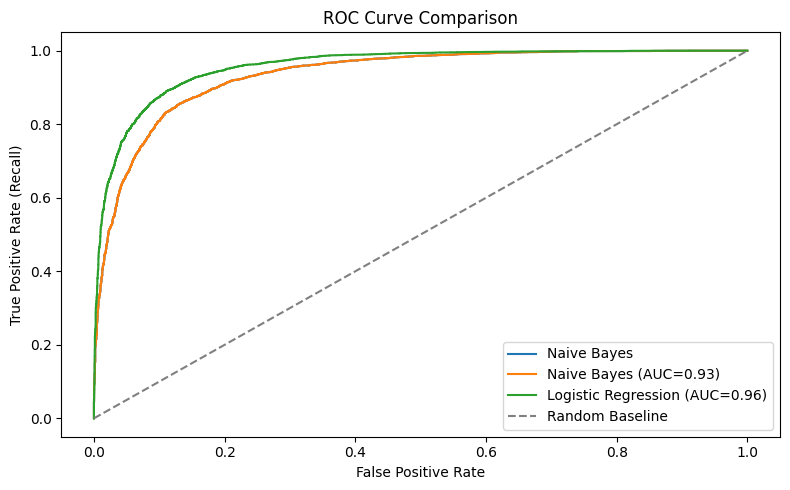

In [36]:
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_nb_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_lr_proba)
plt.figure(figsize=(8, 5))
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes")
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC={roc_auc_score(y_test,y_nb_proba):.2f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test,y_lr_proba):.2f})")
plt.plot([0,1],[0,1], "--", color="grey", label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison")
plt.legend(); plt.tight_layout(); 
plt.show()

In [40]:
import numpy as np

feature_name = tfidf.get_feature_names_out()
lr_coef = lr.coef_[0]
top_positive_index = np.argsort(lr_coef)[-10:][::-1]
print("Top 10 Positive Words:", [feature_name[i] for i in top_positive_index])

top_negative_index = np.argsort(lr_coef)[:10]
print("Top 10 Negative Words:", [feature_name[i] for i in top_negative_index])

Top 10 Positive Words: ['excel', 'perfect', 'great', 'brilliant', 'enjoy', 'favorit', 'amaz', 'hilari', 'superb', 'today']
Top 10 Negative Words: ['worst', 'aw', 'wast', 'bore', 'bad', 'terribl', 'poor', 'disappoint', 'fail', 'dull']
